# Notebook 05 — Modeling: Project-Level Classification (Operational / Per-Grant Triage)
**Label:** `funding_tier` — 4 classes based on individual project federal share:
- 0 = Micro (<$10k) | 1 = Small ($10k–$131k) | 2 = Large ($131k–$1M) | 3 = Major (>$1M)

**Use case:** Local recovery coordinators triaging individual project grant applications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics, PROJECT_LABELS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PROCESSED = '../data/processed/'
proj = pd.read_csv(PROCESSED + 'cleaned_project_level.csv', low_memory=False)
print('Project-level shape:', proj.shape)
proj.head(3)

Project-level shape: (809734, 33)


,disasterNumber,declarationDate,incidentType,pwNumber,applicationTitle,applicantId,damageCategoryCode,damageCategoryDescrip,projectStatus,projectProcessStep,...,poverty_rate,population,risk_score,risk_rating,declaration_lag_days,incident_duration_days,incident_season,incident_year,prior_disasters_5yr,funding_tier
0,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),1,(PW# 1) IMMEDIATE NEEDS FUNDING,465-19792-00,B,Emergency Protective Measures,Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,1
1,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),5,(PW# 5) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,1
2,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),7,(PW# 7) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,1


## 5.1 Define Features & Target
Note: `damageCategoryCode` is included here (not in disaster-level model) — it's known per-project.


In [2]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'damageCategoryCode', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'funding_tier'

CAT_FEATURES = [c for c in CAT_FEATURES if c in proj.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in proj.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = proj[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)
print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)
print('\nClass distribution:')
for t, n in df_model[TARGET].value_counts().sort_index().items():
    print(f'  Tier {t} {PROJECT_LABELS[t]:<25} {n:>8,}  ({100*n/len(df_model):.1f}%)')

Modeling rows: 809,734  |  Features: 11
Categorical: ['incidentType', 'stateAbbreviation', 'damageCategoryCode', 'incident_season']
Numeric:     ['declaration_lag_days', 'incident_duration_days', 'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']

Class distribution:
  Tier 0 Micro (<$10k)              393,733  (48.6%)
  Tier 1 Small ($10k–$131k)         321,607  (39.7%)
  Tier 2 Large ($131k–$1M)           72,212  (8.9%)
  Tier 3 Major (>$1M)                22,182  (2.7%)


## 5.2 Time-Based Train / Test Split


In [3]:
SPLIT_YEAR = 2018
train = df_model[df_model['incident_year'] <  SPLIT_YEAR]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')


Train: 654,534  |  Test: 155,200


## 5.3 Train & Evaluate Models


In [4]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])

TARGET_NAMES = [PROJECT_LABELS[i] for i in range(4)]

models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced',
                                                random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results_project = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    m = classification_metrics(y_test.values, preds, label=name,
                               target_names=TARGET_NAMES)
    m['pipeline'] = pipe
    m['preds']    = preds
    results_project[name] = m


  Baseline (Stratified)
  Accuracy   :   0.3331
  F1 (wtd)   :   0.3166

                    precision    recall  f1-score   support

     Micro (<$10k)       0.24      0.55      0.34     37731
Small ($10k–$131k)       0.50      0.37      0.43     77853
 Large ($131k–$1M)       0.19      0.07      0.10     28879
      Major (>$1M)       0.07      0.02      0.03     10737

          accuracy                           0.33    155200
         macro avg       0.25      0.25      0.22    155200
      weighted avg       0.35      0.33      0.32    155200


  Logistic Regression
  Accuracy   :   0.2859
  F1 (wtd)   :   0.2990

                    precision    recall  f1-score   support

     Micro (<$10k)       0.37      0.40      0.39     37731
Small ($10k–$131k)       0.58      0.21      0.30     77853
 Large ($131k–$1M)       0.21      0.19      0.20     28879
      Major (>$1M)       0.13      0.71      0.21     10737

          accuracy                           0.29    155200
         

## 5.4 Results Summary Table


In [5]:
summary = pd.DataFrame([
    {k: v for k, v in v.items() if k not in ('pipeline', 'preds')}
    for v in results_project.values()
]).set_index('label')
summary[['Accuracy', 'F1_weighted']]

,Accuracy,F1_weighted
label,,
Baseline (Stratified),0.333093,0.316561
Logistic Regression,0.285909,0.299017
Random Forest,0.374897,0.350631
Gradient Boosting,0.314465,0.243207


## 5.5 Feature Importances — Random Forest


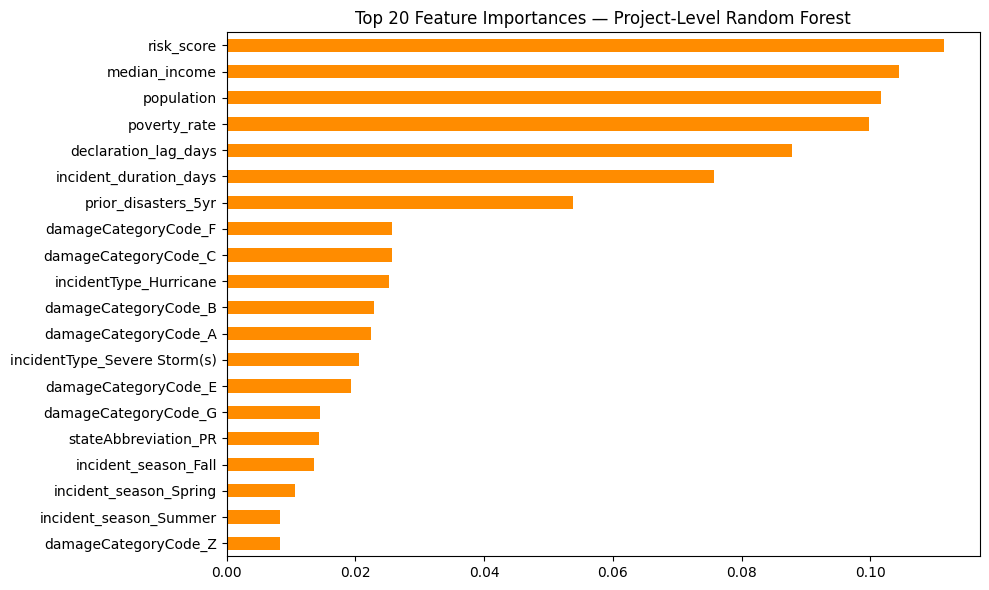

In [6]:
rf_pipe  = results_project['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['pre']

ohe_names = rf_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names = list(ohe_names) + NUM_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_names)
importances.nlargest(20).sort_values().plot(
    kind='barh', figsize=(10, 6),
    title='Top 20 Feature Importances — Project-Level Random Forest',
    color='darkorange'
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_project.png', dpi=150)
plt.show()


## 5.6 Save Best Pipeline


In [7]:
best_name = max(results_project, key=lambda k: results_project[k]['F1_weighted'])
print(f'Best model: {best_name}  (F1_weighted = {results_project[best_name]["F1_weighted"]:.4f})')

with open(PROCESSED + 'best_project_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_project[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_project[best_name]['preds'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'project',
    }, f)
print('Saved best_project_model.pkl')

Best model: Random Forest  (F1_weighted = 0.3506)
Saved best_project_model.pkl
